# 디지털 서비스 교역에서 거리 효과의 지속 — 재현 노트북

`paper.md`가 인용하는 모든 수치와 그림 하나를 이 노트북 하나로 만든다. 위에서 아래로 실행하면
`img/`의 그림이 갱신되고, 마지막 절이 본문의 수치를 하나씩 대조해 어긋나면 `AssertionError`로
멈춘다. 중간 산출물을 파일로 남기지 않는다. 전체 실행에 1시간 안팎이 걸린다(2026-09-24 실측 53분).

필요한 것

- 이 저장소의 `data/processed/svcdb.duckdb` (BaTIS 2025년 12월판)
- `data/external/cepii-gravity/Gravity_csv_V202211.zip` (CEPII Gravity V202211). 압축을 푼 CSV가
  `data/interim/cepii-gravity/`에 없으면 이 노트북이 푼다
- 파이썬 패키지 `pyfixest` (0.60.0에서 실행했다)

## §0. 설정

경로, 그림 표준, 문서 전체에서 쓰는 상수를 둔다. 분석 기간은 2010\~2023년이다. 2010년에 Eurostat
국제서비스교역통계가 보고치로 들어오면서 보고 표본의 관측 수가 한 해에 몇 배로 늘어나고, 2024년은
보고가 덜 들어왔다(§2에서 확인한다). 범주는 EBOPS 2010의 대분류 여덟이다. 운송과 여행을 비교
기준으로 두고, 보험·연금, 금융, 지식재산권 사용료, 통신·컴퓨터·정보, 기타 사업, 개인·문화·여가
여섯을 디지털 전달 가능 서비스(이하 디지털 서비스)로 둔다(IMF et al., 2023).

추정은 모두 PPML이고 표준오차는 나라쌍(수출국과 수입국의 순서쌍) 군집이다. 고정효과 제거는 LSMR로 한다. 기본값인
교대 투영(MAP)이 두 범주를 쌓은 식 하나에서 10만 회 안에 수렴하지 않았기 때문이다. 수렴한
식에서는 두 방법의 계수가 소수 다섯째 자리까지 같았다(2026-09-24 확인).

In [1]:
import json, time, warnings, zipfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

HERE = Path.cwd()
if not (HERE / "paper.md").exists() and (HERE / "research" / "03-digital-distance").exists():
    HERE = HERE / "research" / "03-digital-distance"
assert (HERE / "paper.md").exists(), f"연구 폴더에서 실행한다 (지금: {HERE})"
ROOT = HERE.parents[1]
DB = ROOT / "data" / "processed" / "svcdb.duckdb"
GZIP = ROOT / "data" / "external" / "cepii-gravity" / "Gravity_csv_V202211.zip"
GCSV = ROOT / "data" / "interim" / "cepii-gravity" / "Gravity_V202211.csv"
IMG = HERE / "img"
IMG.mkdir(exist_ok=True)
assert DB.exists(), f"서비스 교역 DB가 없다: {DB}"
assert GZIP.exists() or GCSV.exists(), f"CEPII Gravity가 없다: {GZIP}"

plt.rcParams.update({
    "font.family": "Malgun Gothic", "axes.unicode_minus": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "0.87", "grid.linewidth": 0.8,
    "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
})
pd.set_option("display.width", 170)

Y0, Y1 = 2010, 2023
BASE = ["SC", "SD"]
DIGITAL = ["SF", "SG", "SH", "SI", "SJ", "SK"]
ITEMS = BASE + DIGITAL
NAME = {"SC": "운송", "SD": "여행", "SF": "보험·연금", "SG": "금융", "SH": "지식재산권 사용료",
        "SI": "통신·컴퓨터·정보", "SJ": "기타 사업", "SK": "개인·문화·여가"}
EU27 = {"AUT", "BEL", "BGR", "HRV", "CYP", "CZE", "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN",
        "IRL", "ITA", "LVA", "LTU", "LUX", "MLT", "NLD", "POL", "PRT", "ROU", "SVK", "SVN", "ESP", "SWE"}
GCHINA = {"CHN", "HKG", "MAC", "TWN"}
S: dict = {}

DM = pf.LsmrDemeaner(fixef_maxiter=100_000, fixef_atol=1e-10, fixef_btol=1e-10)


def ppml(d, rhs, fe):
    return pf.fepois(f"v ~ {rhs} | {fe}", data=d, vcov={"CRV1": "pair"},
                     demeaner=DM, iwls_maxiter=100)


def coef(m, var):
    t = m.tidy().loc[var]
    return {"b": float(t["Estimate"]), "se": float(t["Std. Error"]),
            "p": float(t["Pr(>|t|)"]), "n": int(m._N)}


def r(x, n=3):
    return None if x is None or (isinstance(x, float) and np.isnan(x)) else round(float(x), n)

## §1. 거리와 통제변수

CEPII Gravity V202211에서 거리와 세 통제변수를 가져온다(III.2절). 거리는 인구 가중 조화평균
거리(`distw_harmonic`)이고, 강건성 확인을 위해 대표 도시 간 거리(`dist`)와 수도 간 거리(`distcap`)도
함께 둔다. 통제변수는 국경 인접(`contig`), 공용어(`comlang_off`), 식민 관계(`col_dep_ever`)이며
BaTIS가 보고치 없는 교역을 추정할 때 쓴 교역비용 변수와 같다(OECD and WTO, 2025b).

BaTIS 코드는 Gravity의 iso3와 맞춘다. Gravity는 국경이 바뀐 나라에 `DEU.2` 꼴의 번호를 붙이므로
`country_id`로 맞추면 여덟 나라가 빠진다. 옛 네덜란드령 안틸레스(`ANT_F`)는 `ANT`로 맞추고,
Gravity에 없는 코소보(`XKV`)는 뺀다. 시간에 따라 변하지 않는 변수이므로 2010\~2021년 가운데 두
나라가 모두 존재한 가장 늦은 해의 값을 두 나라 사이에 하나 붙인다. Gravity가 2021년에서 끝나도
2022\~2023년 관측에 같은 값을 쓸 수 있는 이유다.

In [2]:
if not GCSV.exists():
    GCSV.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(GZIP) as z:
        z.extract(GCSV.name, GCSV.parent)

con = duckdb.connect()
con.execute(f"ATTACH '{DB.as_posix()}' AS s (READ_ONLY)")
S["edition"] = con.execute("SELECT DISTINCT edition FROM s.fact_batis").fetchall()
assert S["edition"] == [("2025-12",)], S["edition"]

GV = ["distw_harmonic", "dist", "distcap", "contig", "comlang_off", "col_dep_ever"]
con.execute(f"""
CREATE TEMP TABLE g_pair AS
SELECT iso3_o, iso3_d, {", ".join(f'arg_max({v}, "year") AS {v}' for v in GV)}
FROM read_csv('{GCSV.as_posix()}', auto_detect=true, sample_size=-1)
WHERE "year" BETWEEN {Y0} AND 2021 AND country_exists_o = 1 AND country_exists_d = 1
  AND iso3_o <> iso3_d
GROUP BY 1, 2
""")
S["g_pairs"] = con.execute("SELECT count(*) FROM g_pair").fetchone()[0]
print("Gravity 나라쌍:", S["g_pairs"])

Gravity 나라쌍: 55458


## §2. 보고 표본

나라쌍 $(i, j)$의 관측은 $i$의 수출 보고(보고국 $i$, 상대국 $j$) 또는 $j$의 수입 보고(보고국 $j$,
상대국 $i$) 가운데 하나라도 방법론 코드가 보고치(`R_`로 시작)이면 보고 표본에 넣는다(III.1절).
값은 두 보고를 화해시킨 균형치를 쓴다. 추정으로 채운 값도 지우지 않고 `obs = False`로 남겨
표 2의 금액 비중을 구할 때 분모에 쓴다. 집계 코드와 잔여 코드(`WXD`)는 뺀다.

이 절은 기간을 2010\~2023년으로 정한 근거(2009\~2010년의 보고 급증과 2024년의 미완결)와 표 2의
범주별 보고 범위를 함께 계산한다.

In [3]:
# 기간 선택의 근거: 총서비스의 관측 흐름 수와 2010년에 새로 들어온 출처
yr_obs = con.execute("""
WITH ind AS (SELECT code FROM s.dim_area WHERE NOT is_aggregate AND code <> 'WXD'),
b AS (SELECT f.reporter, f.partner, f.flow, f.year, f.methodology
      FROM s.fact_batis f JOIN s.dim_methodology m ON f.methodology = m.code
      WHERE m.mclass = 'reported' AND f.item_code = 'S'
        AND f.reporter IN (SELECT code FROM ind) AND f.partner IN (SELECT code FROM ind))
SELECT year, count(DISTINCT CASE WHEN flow = 'EXP' THEN reporter || '>' || partner
                                 ELSE partner || '>' || reporter END) AS n
FROM b GROUP BY 1 ORDER BY 1
""").df().set_index("year").n
src10 = con.execute("""
SELECT methodology, count(*) n FROM s.fact_batis
WHERE item_code = 'S' AND year = 2010
  AND methodology IN (SELECT code FROM s.dim_methodology WHERE mclass = 'reported')
  AND reporter NOT IN (SELECT code FROM s.dim_area WHERE is_aggregate OR code = 'WXD')
  AND partner  NOT IN (SELECT code FROM s.dim_area WHERE is_aggregate OR code = 'WXD')
GROUP BY 1 ORDER BY 2 DESC""").df()
S["S_obs_2009"], S["S_obs_2010"] = int(yr_obs[2009]), int(yr_obs[2010])
S["S_obs_2023"], S["S_obs_2024"] = int(yr_obs[2023]), int(yr_obs[2024])
S["S_2010_eu_its_share"] = r(100 * src10.set_index("methodology").n.get("R_EU_ITS", 0) / src10.n.sum(), 1)
# 서비스 수출에서 디지털 여섯 범주와 운송·여행이 차지하는 비중(I장). 추정 칸을 포함한 개별 경제 사이 균형치다
mix = con.execute(f"""
WITH ind AS (SELECT code FROM s.dim_area WHERE NOT is_aggregate AND code <> 'WXD')
SELECT year, item_code, sum(balanced_value) AS v FROM s.fact_batis
WHERE flow = 'EXP' AND year IN ({Y0}, {Y1}) AND item_code IN ('S', {", ".join(f"'{x}'" for x in ITEMS)})
  AND reporter IN (SELECT code FROM ind) AND partner IN (SELECT code FROM ind)
GROUP BY 1, 2""").df().pivot(index="year", columns="item_code", values="v")
S["mix"] = {str(y): {"digital": r(100 * mix.loc[y, DIGITAL].sum() / mix.loc[y, "S"], 1),
                     "base": r(100 * mix.loc[y, BASE].sum() / mix.loc[y, "S"], 1),
                     "SI": r(100 * mix.loc[y, "SI"] / mix.loc[y, "S"], 1)} for y in (Y0, Y1)}
print(S["mix"])
# 코소보가 포함된 관측 흐름의 비중(III.2절). Gravity에 없어 분석에서 빠진다.
xkv = con.execute(f"""
WITH ind AS (SELECT code FROM s.dim_area WHERE NOT is_aggregate AND code <> 'WXD'),
b AS (SELECT f.reporter, f.partner, f.flow, f.item_code, f.year, f.balanced_value,
             m.mclass = 'reported' AS rep
      FROM s.fact_batis f JOIN s.dim_methodology m ON f.methodology = m.code
      WHERE f.year BETWEEN {Y0} AND {Y1} AND f.item_code IN ({", ".join(f"'{x}'" for x in ITEMS)})
        AND f.reporter IN (SELECT code FROM ind) AND f.partner IN (SELECT code FROM ind)),
e AS (SELECT reporter AS i, partner AS j, item_code, year, balanced_value AS v, rep AS rx FROM b WHERE flow = 'EXP'),
m AS (SELECT partner AS i, reporter AS j, item_code, year, rep AS rm FROM b WHERE flow = 'IMP'),
o AS (SELECT e.* FROM e LEFT JOIN m USING (i, j, item_code, year) WHERE e.rx OR coalesce(m.rm, false))
SELECT item_code, 100 * avg(('XKV' IN (i, j))::INT) AS rows,
       100 * sum(v) FILTER (WHERE 'XKV' IN (i, j)) / sum(v) AS value
FROM o GROUP BY 1""").df().set_index("item_code")
S["xkv"] = {it: {"rows": r(xkv.rows[it], 2), "value": r(xkv.value[it], 4)} for it in ITEMS}
print(yr_obs.to_string())
print(xkv.round(3).to_string())
print(src10.to_string(index=False))

year
2005      814
2006     1004
2007     1072
2008     1472
2009     1641
2010     7481
2011     7967
2012     8423
2013     9566
2014     9775
2015    10211
2016    10031
2017    10475
2018    10730
2019    10631
2020    10669
2021    10630
2022    10780
2023    10987
2024     2658
            rows  value
item_code              
SC         0.931  0.020
SD         1.307  0.079
SF         1.256  0.009
SG         0.295  0.001
SH         0.239  0.001
SJ         1.176  0.011
SK         0.595  0.006
SI         1.014  0.016
methodology    n
   R_EU_ITS 6490
      R_NAT  687
     R_OECD  591
  R_EU_EBOP  177


In [4]:
items_sql = ", ".join(f"'{x}'" for x in ITEMS)
con.execute(f"""
CREATE TEMP TABLE flows AS
WITH ind AS (SELECT code FROM s.dim_area
             WHERE NOT is_aggregate AND code NOT IN ('WXD', 'XKV')),
b AS (SELECT f.reporter, f.partner, f.flow, f.item_code, f.year, f.balanced_value,
             m.mclass = 'reported' AS rep
      FROM s.fact_batis f JOIN s.dim_methodology m ON f.methodology = m.code
      WHERE f.year BETWEEN {Y0} AND {Y1} AND f.item_code IN ({items_sql})
        AND f.reporter IN (SELECT code FROM ind) AND f.partner IN (SELECT code FROM ind)),
e AS (SELECT reporter AS i, partner AS j, item_code, year, balanced_value AS v, rep AS rx
      FROM b WHERE flow = 'EXP'),
m AS (SELECT partner AS i, reporter AS j, item_code, year, rep AS rm FROM b WHERE flow = 'IMP')
SELECT e.i, e.j, e.item_code, e.year, e.v,
       coalesce(e.rx, false) AS rx, coalesce(m.rm, false) AS rm,
       coalesce(e.rx, false) OR coalesce(m.rm, false) AS obs
FROM e LEFT JOIN m USING (i, j, item_code, year)
""")
key = "CASE WHEN {x} = 'ANT_F' THEN 'ANT' ELSE {x} END"
df = con.execute(f"""
SELECT f.*, g.distw_harmonic, g.dist, g.distcap, g.contig, g.comlang_off, g.col_dep_ever
FROM flows f LEFT JOIN g_pair g
  ON g.iso3_o = {key.format(x='f.i')} AND g.iso3_d = {key.format(x='f.j')}
""").df()
assert df.distw_harmonic.notna().all(), "Gravity와 맞지 않는 흐름이 있다"

# Gravity가 식민 관계를 비워 둔 나라쌍은 0으로 둔다(중국과 홍콩·대만 사이). 공용어가 빈 흐름은 뺀다.
miss_col = df[df.col_dep_ever.isna() & df.comlang_off.notna() & df.obs]
S["col_fill_pairs"] = sorted(set(miss_col.i + "-" + miss_col.j))
S["col_fill_value_share"] = r(100 * miss_col.v.sum() / df[df.obs].v.sum(), 2)
df["col_dep_ever"] = df.col_dep_ever.fillna(0)
drop = df.comlang_off.isna()
S["comlang_drop_obs_rows"] = int((drop & df.obs).sum())
S["comlang_drop_obs_value_share"] = r(100 * df[drop & df.obs].v.sum() / df[df.obs].v.sum(), 4)
df = df[~drop].copy()
for c in ("contig", "comlang_off", "col_dep_ever"):
    df[c] = df[c].astype(float)

df["ldist"] = np.log(df.distw_harmonic)
df["year"] = df.year.astype(int)
df["pair"] = df.i + ">" + df.j
df["ey"] = df.i + "_" + df.year.astype(str)
df["iy"] = df.j + "_" + df.year.astype(str)
df["ld_t"] = df.ldist * (df.year - Y0)
print(S["col_fill_pairs"], S["col_fill_value_share"], S["comlang_drop_obs_rows"],
      S["comlang_drop_obs_value_share"])
print(df.groupby("item_code").obs.agg(["size", "sum"]))

['CHN-HKG', 'CHN-TWN', 'HKG-CHN', 'TWN-CHN'] 2.17 260 0.0005
             size    sum
item_code               
SC         540962  53780
SD         540962  48772
SF         540962  42128
SG         540962  44963
SH         540962  40463
SI         540962  47597
SJ         540962  49873
SK         540962  39207


표 2의 열은 차례로 2010\~2023년 보고 표본의 관측 수, 그 관측이 이루는 나라쌍 수, 해당 범주를 한
해라도 상대국별로 보고한 경제의 수, 보고 표본의 균형치가 전체 표본의 균형치 합계에서 차지하는 비중,
보고 표본 가운데 수출국과 수입국이 모두 보고한 관측의 비중이다.

In [5]:
obs = df[df.obs]
rep_econ = {it: len(set(obs[(obs.item_code == it) & obs.rx].i) | set(obs[(obs.item_code == it) & obs.rm].j))
            for it in ITEMS}
t1 = pd.DataFrame({
    "flows": obs.groupby("item_code").size(),
    "pairs": obs.groupby("item_code").pair.nunique(),
    "reporters": pd.Series(rep_econ),
    "val_cov": 100 * obs.groupby("item_code").v.sum() / df.groupby("item_code").v.sum(),
    "both": 100 * obs.groupby("item_code").apply(lambda d: (d.rx & d.rm).mean(), include_groups=False),
}).loc[ITEMS]
S["eu_reporters"] = {it: len({e for e in (set(obs[(obs.item_code == it) & obs.rx].i)
                                             | set(obs[(obs.item_code == it) & obs.rm].j)) if e in EU27})
                      for it in ITEMS}
S["t1"] = {it: {"flows": int(t1.flows[it]), "pairs": int(t1.pairs[it]), "reporters": int(t1.reporters[it]),
                "val_cov": r(t1.val_cov[it], 1), "both": r(t1.both[it], 1)} for it in ITEMS}
S["obs_rows_share"] = r(100 * len(obs) / len(df), 1)
S["obs_value_share"] = r(100 * obs.v.sum() / df.v.sum(), 1)
S["n_all_rows"] = int(len(df))
S["n_obs_rows"] = int(len(obs))
t1.index = [NAME[i] for i in t1.index]
print(t1.round(1).to_string())
print("관측 행 비중", S["obs_rows_share"], "금액 비중", S["obs_value_share"])

           flows  pairs  reporters  val_cov  both
운송         53780   5975         58     71.7  20.5
여행         48772   5282         58     66.7  19.8
보험·연금      42128   4271         51     74.6  26.3
금융         44963   4543         55     85.5  27.9
지식재산권 사용료  40463   4212         56     86.2  26.5
통신·컴퓨터·정보  47597   5325         58     77.0  20.1
기타 사업      49873   5513         58     76.7  20.1
개인·문화·여가   39207   4491         55     65.3  19.8
관측 행 비중 8.5 금액 비중 74.7


## §3. 범주별 거리 탄력성

표 3의 식 (1)이다. 수출국×연도 및 수입국×연도의 고정효과를 넣고 2010\~2023년을 합동으로 추정한다.

In [6]:
CTRL = "contig + comlang_off + col_dep_ever"
S["t2"] = {}
t0 = time.time()
for it in ITEMS:
    d = df[df.item_code == it]
    mo = ppml(d[d.obs], f"ldist + {CTRL}", "ey + iy")
    S["t2"][it] = {"obs": {v: coef(mo, v) for v in ["ldist", "contig", "comlang_off", "col_dep_ever"]}}
    print(it, round(S["t2"][it]["obs"]["ldist"]["b"], 3), f"{time.time() - t0:.0f}s", flush=True)

# 거리 정의를 바꾼 확인(본문 IV.1절의 한 문장)
S["t2_altdist"] = {}
for it in ITEMS:
    d = df[(df.item_code == it) & df.obs].copy()
    out = {}
    for nm in ("dist", "distcap"):
        d["ld_alt"] = np.log(d[nm])
        out[nm] = coef(ppml(d, f"ld_alt + {CTRL}", "ey + iy"), "ld_alt")["b"]
    S["t2_altdist"][it] = out
t2 = pd.DataFrame({NAME[it]: {"obs": S["t2"][it]["obs"]["ldist"]["b"], "se": S["t2"][it]["obs"]["ldist"]["se"],
                              "contig": S["t2"][it]["obs"]["contig"]["b"],
                              "comlang": S["t2"][it]["obs"]["comlang_off"]["b"],
                              "colony": S["t2"][it]["obs"]["col_dep_ever"]["b"],
                              "dist": S["t2_altdist"][it]["dist"], "distcap": S["t2_altdist"][it]["distcap"]}
                    for it in ITEMS}).T
print(t2.round(3).to_string())

SC -0.591 6s


SD -0.847 11s


SF -0.682 16s


SG -0.582 23s


SH -0.404 29s


SI -0.681 36s


SJ -0.539 43s


SK -0.708 48s


             obs     se  contig  comlang  colony   dist  distcap
운송        -0.591  0.023   0.244    0.135   0.153 -0.564   -0.583
여행        -0.847  0.031   0.409    0.464   0.220 -0.739   -0.760
보험·연금     -0.682  0.056  -0.052    0.406  -0.345 -0.605   -0.602
금융        -0.582  0.055   0.150    0.394  -0.244 -0.530   -0.538
지식재산권 사용료 -0.404  0.075  -0.167    0.062  -0.474 -0.398   -0.402
통신·컴퓨터·정보 -0.681  0.029  -0.050    0.161  -0.300 -0.653   -0.663
기타 사업     -0.539  0.026   0.050    0.477  -0.315 -0.513   -0.520
개인·문화·여가  -0.708  0.041   0.164    0.479   0.149 -0.625   -0.649


### 범주 간 수준 차이

IV.1절의 검정이다(식 (4)). 표 3의 추정치는 범주별로 따로 구한 것이고 같은 나라쌍이 여러 범주에 함께
나오므로 두 범주의 추정치는 독립이 아니다. 디지털 범주 하나와 비교 범주 하나(운송 또는 여행)를
쌓고, 수출국×연도 및 수입국×연도의 고정효과와 세 통제변수를 모두 범주와 교차시킨 채 로그 거리에
디지털 범주 더미를 곱한 항을 더한다. 그 계수는 디지털 범주의 거리 탄력성에서 비교 범주의 거리
탄력성을 뺀 값이고, 양수이면 디지털 범주가 거리에 덜 민감하다. 표준오차는 범주를 구분하지 않은
나라쌍으로 군집한다. 점추정치는 표 3의 두 추정치의 차이와 같아야 하므로 그것도 함께 확인한다.

In [7]:
S["t2_diff"] = {b: {} for b in BASE}
t0 = time.time()
for base in BASE:
    for it in DIGITAL:
        d = df[df.obs & df.item_code.isin([base, it])].copy()
        d["ey"] = d.ey + d.item_code
        d["iy"] = d.iy + d.item_code
        x = (d.item_code == it).astype(float)
        for v in ("ldist", "contig", "comlang_off", "col_dep_ever"):
            d[f"{v}_x"] = d[v] * x
        rhs = "ldist + ldist_x + " + " + ".join(f"{v} + {v}_x" for v in ("contig", "comlang_off", "col_dep_ever"))
        m = ppml(d, rhs, "ey + iy")
        S["t2_diff"][base][it] = coef(m, "ldist_x")
        # 범주를 모두 교차시켰으므로 점추정치는 따로 구한 두 추정치의 차이와 같다
        sep = S["t2"][it]["obs"]["ldist"]["b"] - S["t2"][base]["obs"]["ldist"]["b"]
        assert abs(S["t2_diff"][base][it]["b"] - sep) < 1e-4, (base, it, S["t2_diff"][base][it]["b"], sep)
        print(base, it, round(S["t2_diff"][base][it]["b"], 3), round(S["t2_diff"][base][it]["p"], 3),
              f"{time.time() - t0:.0f}s", flush=True)
t2d = pd.DataFrame({NAME[it]: {f"{b}_{k}": S["t2_diff"][b][it][k] for b in BASE for k in ("b", "se", "p")}
                    for it in DIGITAL}).T
print(t2d.round(3).to_string())

SC SF -0.091 0.107 13s


SC SG 0.009 0.873 34s


SC SH 0.188 0.014 52s


SC SI -0.089 0.005 66s


SC SJ 0.053 0.06 80s


...

SD SH 0.443 0.0 150s


SD SI 0.166 0.0 167s


SD SJ 0.308 0.0 180s


SD SK 0.139 0.001 196s


            SC_b  SC_se   SC_p   SD_b  SD_se   SD_p
보험·연금     -0.091  0.056  0.107  0.164  0.059  0.005
금융         0.009  0.057  0.873  0.264  0.062  0.000
지식재산권 사용료  0.188  0.076  0.014  0.443  0.081  0.000
통신·컴퓨터·정보 -0.089  0.032  0.005  0.166  0.039  0.000
기타 사업      0.053  0.028  0.060  0.308  0.036  0.000
개인·문화·여가  -0.117  0.043  0.006  0.139  0.044  0.001


### 통제변수를 바꾼 확인

IV.1절의 강건성 문단이다. Li et al. (2025)의 통제변수 조합, 곧 국경 인접, 공용어, 법체계의 공통 기원, 무역협정,
EU 동반 가입으로 식 (1)을 다시 추정한다. 무역협정과 EU 동반 가입은 해마다 바뀌며 Gravity가 끝나는 2021년 이후에는
2021년 값을 쓴다. §6의 `eu2`(두 나라가 모두 현재 EU 27개국)와 구분하려고 해마다 바뀌는 변수는 `eu_both_t`로 부른다.
EU 동반 가입만 더한 추정, 값을 균형치 대신 수출국 보고를 우선한 보고치로 바꾼 추정, 그리고 이 조합에서 디지털 범주와
비교 범주를 쌓은 수준 차이 검정을 함께 구한다.

In [8]:
gv_tv = con.execute(f"""
SELECT "year"::INT AS year, iso3_o, iso3_d, fta_wto AS rta_t, eu_o, eu_d, comleg_posttrans AS comleg_t
FROM read_csv('{GCSV.as_posix()}', auto_detect=true, sample_size=-1)
WHERE "year" BETWEEN {Y0} AND 2021 AND country_exists_o = 1 AND country_exists_d = 1 AND iso3_o <> iso3_d
""").df()
gv_tv["eu_both_t"] = ((gv_tv.eu_o == 1) & (gv_tv.eu_d == 1)).astype(float)
gv_tv = gv_tv.drop(columns=["eu_o", "eu_d"]).drop_duplicates(["year", "iso3_o", "iso3_d"])
gv_tv = pd.concat([gv_tv] + [gv_tv[gv_tv.year == 2021].assign(year=y) for y in range(2022, Y1 + 1)])
n_before = len(df)
df["iso_i"], df["iso_j"] = df.i.replace({"ANT_F": "ANT"}), df.j.replace({"ANT_F": "ANT"})
df = df.merge(gv_tv, left_on=["iso_i", "iso_j", "year"], right_on=["iso3_o", "iso3_d", "year"], how="left")
df = df.drop(columns=["iso3_o", "iso3_d"])
assert len(df) == n_before
for c_ in ("rta_t", "eu_both_t", "comleg_t"):
    df[c_] = df[c_].fillna(0).astype(float)

rep_v = con.execute(f"""
WITH e AS (SELECT reporter i, partner j, item_code, year, reported_value rx FROM s.fact_batis
           WHERE flow = 'EXP' AND year BETWEEN {Y0} AND {Y1} AND item_code IN ({items_sql})),
     m AS (SELECT partner i, reporter j, item_code, year, reported_value rm FROM s.fact_batis
           WHERE flow = 'IMP' AND year BETWEEN {Y0} AND {Y1} AND item_code IN ({items_sql}))
SELECT e.i, e.j, e.item_code, e.year, coalesce(e.rx, m.rm) AS rv FROM e LEFT JOIN m USING (i, j, item_code, year)
""").df()

LI_VARS = ["contig", "comlang_off", "comleg_t", "rta_t", "eu_both_t"]
LI_CTRL = " + ".join(LI_VARS)
S["t2_li"], S["t2_eu"], S["t2_li_rep"] = {}, {}, {}
t0 = time.time()
for it in ITEMS:
    d_li = df[(df.item_code == it) & df.obs]
    S["t2_li"][it] = coef(ppml(d_li, f"ldist + {LI_CTRL}", "ey + iy"), "ldist")
    S["t2_eu"][it] = coef(ppml(d_li, f"ldist + {CTRL} + eu_both_t", "ey + iy"), "ldist")
    d_rv = d_li.merge(rep_v, on=["i", "j", "item_code", "year"], how="left")
    d_rv = d_rv[d_rv.rv.notna() & (d_rv.rv >= 0)].assign(v=lambda x: x.rv)
    S["t2_li_rep"][it] = coef(ppml(d_rv, f"ldist + {LI_CTRL}", "ey + iy"), "ldist")
    print(it, round(S["t2_li"][it]["b"], 3), round(S["t2_eu"][it]["b"], 3), round(S["t2_li_rep"][it]["b"], 3),
          f"{time.time() - t0:.0f}s", flush=True)

S["t2_li_diff"] = {b: {} for b in BASE}
for base in BASE:
    for it in DIGITAL:
        d_li = df[df.obs & df.item_code.isin([base, it])].copy()
        d_li["ey"] = d_li.ey + d_li.item_code
        d_li["iy"] = d_li.iy + d_li.item_code
        dm_ = (d_li.item_code == it).astype(float)
        for v_ in ["ldist"] + LI_VARS:
            d_li[f"{v_}_x"] = d_li[v_] * dm_
        rhs_ = " + ".join(f"{v_} + {v_}_x" for v_ in ["ldist"] + LI_VARS)
        S["t2_li_diff"][base][it] = coef(ppml(d_li, rhs_, "ey + iy"), "ldist_x")
        print(base, it, round(S["t2_li_diff"][base][it]["b"], 3), round(S["t2_li_diff"][base][it]["p"], 3),
              f"{time.time() - t0:.0f}s", flush=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

SC -0.533 -0.549 -0.563 21s


SD -0.791 -0.784 -0.867 40s


SF -0.638 -0.608 -0.592 57s


SG -0.56 -0.528 -0.54 82s


...

SD SG 0.231 0.001 384s


SD SH 0.456 0.0 413s


SD SI 0.204 0.0 443s


SD SJ 0.316 0.0 464s


SD SK 0.171 0.001 489s


## §4. 거리 탄력성의 추세

식 (2)와 식 (3)이다. 나라쌍 고정효과를 더하면 거리의 수준과 시간 불변 통제변수가 모두 흡수되고,
같은 수출국과 수입국 사이에서 거리 계수가 2010년에 비해 얼마나 달라졌는지만 남는다. 식 (2)는 로그 거리에
연도 더미를 곱한 13개 계수로 그림 1을 만들고, 식 (3)은 로그 거리에 2010년부터의 경과 연수를 곱한
계수 하나로 연간 변화를 요약한다(표 4).

In [9]:
YRS = list(range(Y0 + 1, Y1 + 1))
S["year"], S["trend"] = {}, {}
t0 = time.time()
for it in ITEMS:
    d = df[(df.item_code == it) & df.obs].copy()
    for y in YRS:
        d[f"ld_{y}"] = np.where(d.year == y, d.ldist, 0.0)
    m = ppml(d, " + ".join(f"ld_{y}" for y in YRS), "ey + iy + pair")
    S["year"][it] = {y: coef(m, f"ld_{y}") for y in YRS}
    S["trend"][it] = coef(ppml(d, "ld_t", "ey + iy + pair"), "ld_t")
    S["trend"][it]["pairs"] = int(d.pair.nunique())
    print(it, "obs", round(S["trend"][it]["b"], 4), f"{time.time() - t0:.0f}s", flush=True)

t3 = pd.DataFrame({NAME[it]: {"b": S["trend"][it]["b"], "se": S["trend"][it]["se"],
                              "cum13": 13 * S["trend"][it]["b"], "n": S["trend"][it]["n"],
                              "pairs": S["trend"][it]["pairs"]}
                   for it in ITEMS}).T
print(t3.round(4).to_string())

SC obs 0.004 71s


SD obs 0.0042 168s


SF obs 0.0084 268s


SG obs -0.0044 385s


SH obs 0.0089 470s


SI obs 0.0075 549s


SJ obs 0.0032 656s


SK obs 0.0103 745s


                b      se   cum13        n   pairs
운송         0.0040  0.0014  0.0522  52758.0  5975.0
여행         0.0042  0.0015  0.0540  47760.0  5282.0
보험·연금      0.0084  0.0032  0.1086  40318.0  4271.0
금융        -0.0044  0.0025 -0.0570  43311.0  4543.0
지식재산권 사용료  0.0089  0.0053  0.1156  38376.0  4212.0
통신·컴퓨터·정보  0.0075  0.0023  0.0976  46417.0  5325.0
기타 사업      0.0032  0.0015  0.0422  48718.0  5513.0
개인·문화·여가   0.0103  0.0039  0.1335  37299.0  4491.0


## §5. 그림 1 — 연도별 거리 계수의 변화

식 (2)의 13개 계수를 범주별로 그린다. IV.2절이 묻는 것은 변화가 언제 일어났는가이므로 연 단위
계열을 그림으로 둔다. 띠는 95% 신뢰구간이고 점선은 2010년 수준이다.

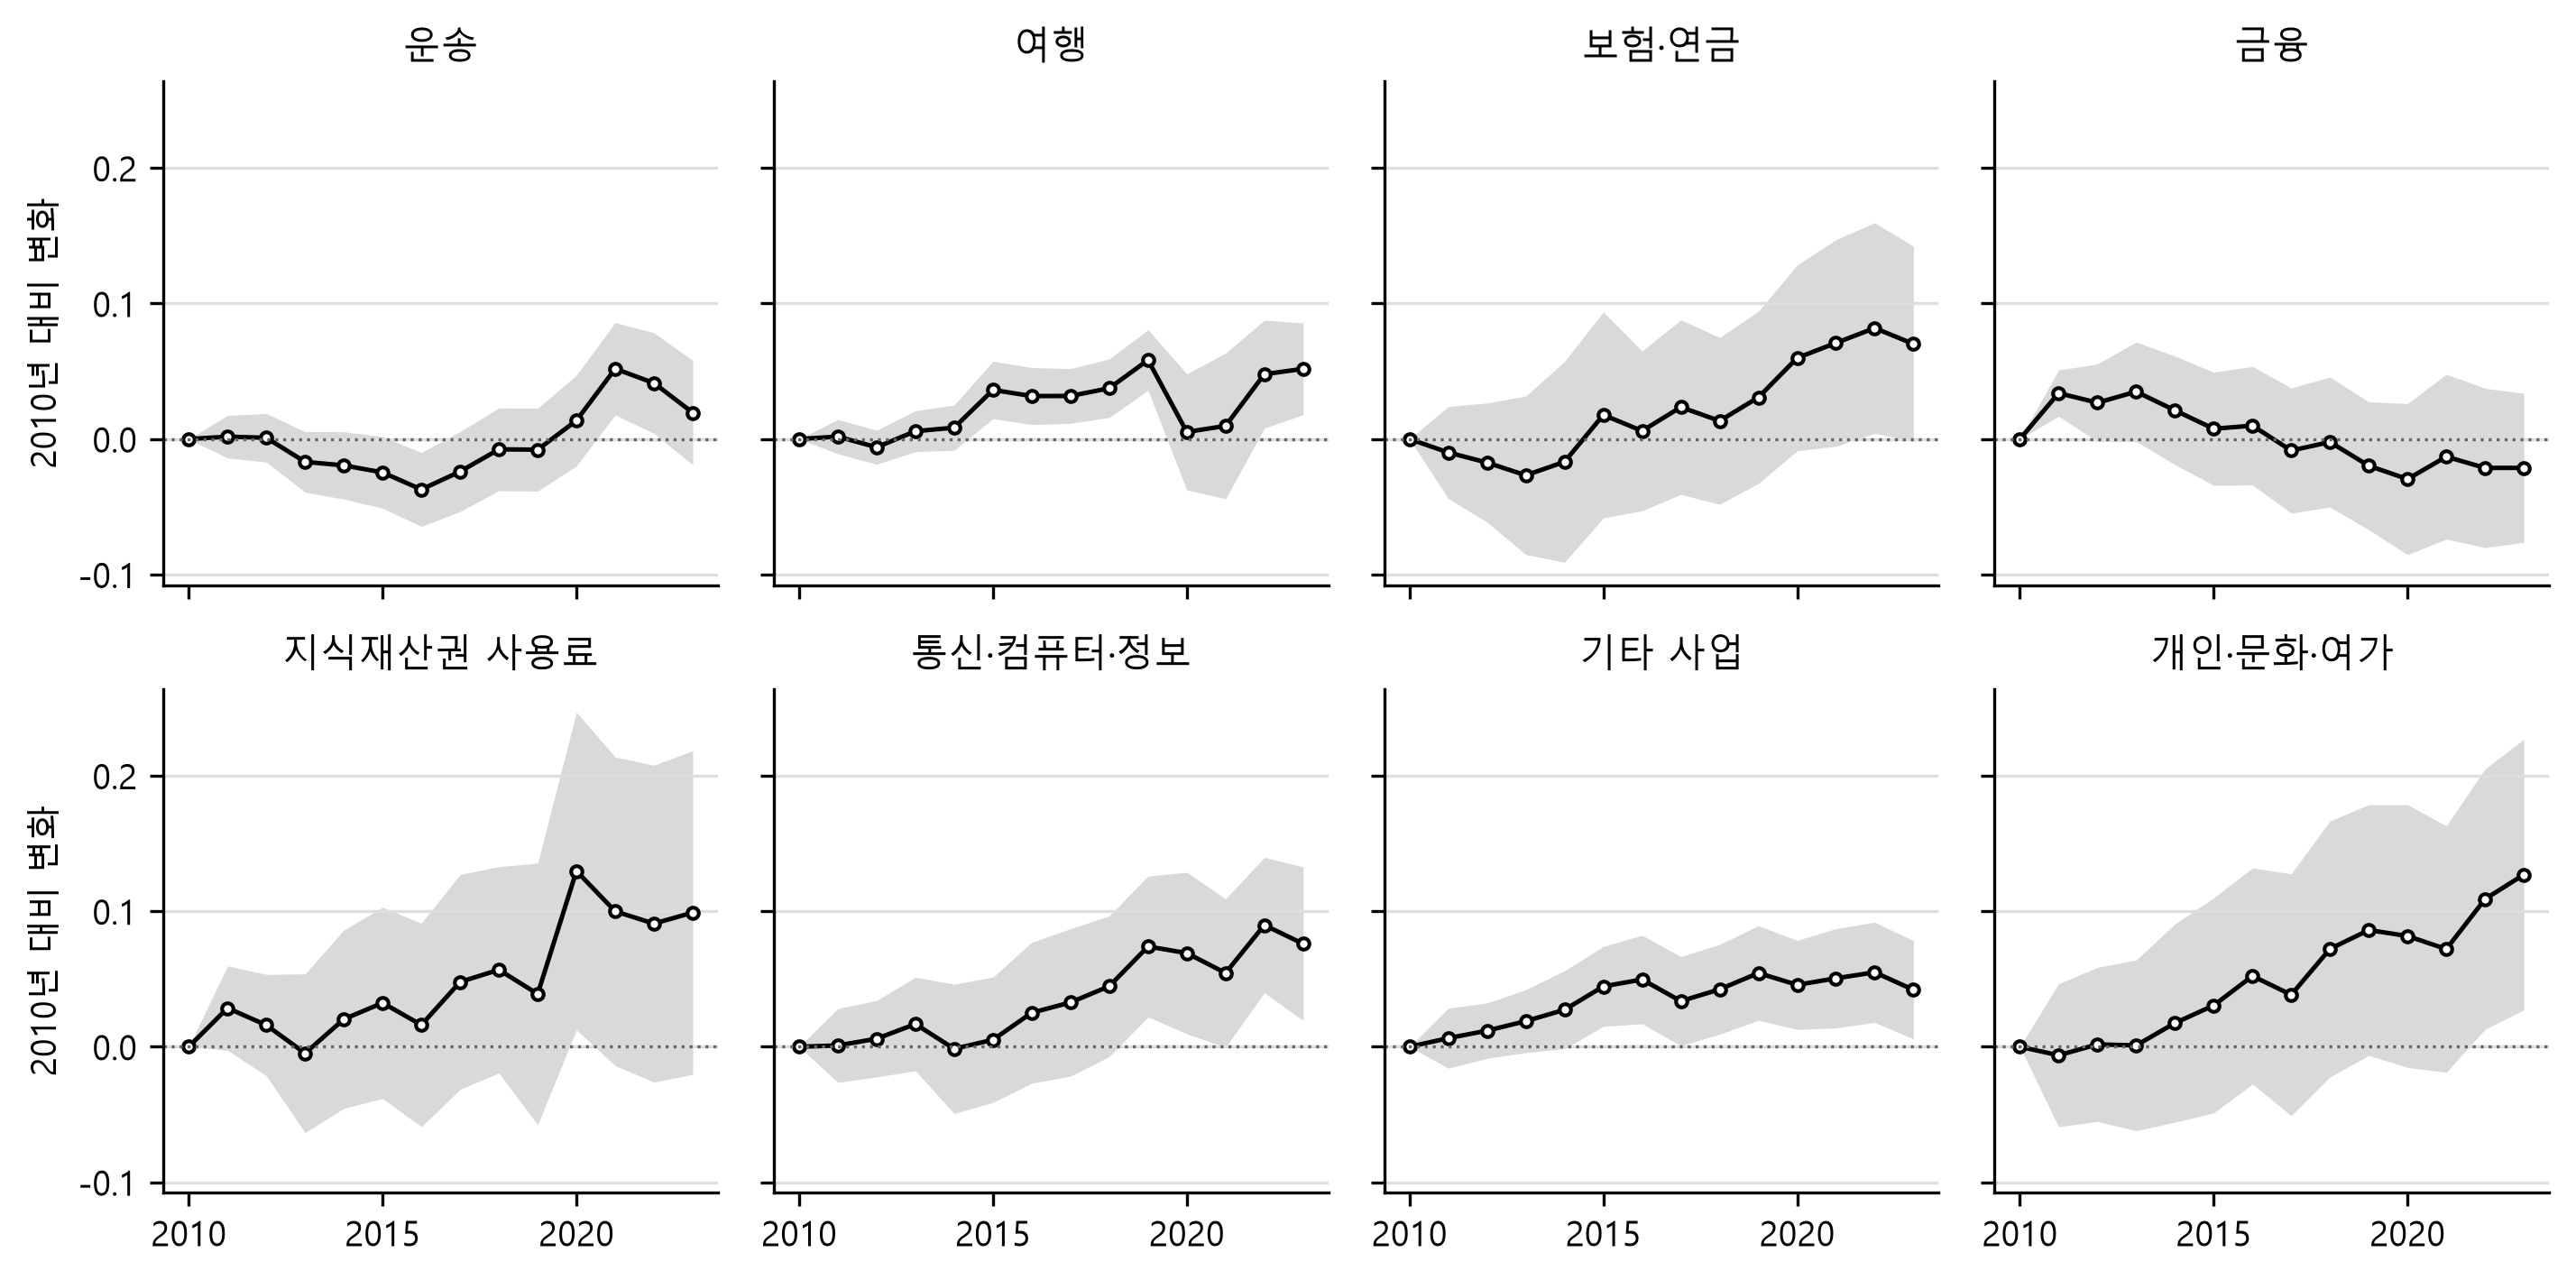

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(9.6, 4.8), sharex=True, sharey=True)
for ax, it in zip(axes.flat, ITEMS):
    ys = [Y0] + YRS
    b = np.array([0.0] + [S["year"][it][y]["b"] for y in YRS])
    se = np.array([0.0] + [S["year"][it][y]["se"] for y in YRS])
    ax.fill_between(ys, b - 1.96 * se, b + 1.96 * se, color="0.85", lw=0)
    ax.plot(ys, b, color="black", lw=1.2, marker="o", ms=3, mfc="white")
    ax.axhline(0, color="0.4", lw=0.8, ls=":")
    ax.set_title(NAME[it])
    ax.set_xticks([2010, 2015, 2020])
for ax in axes[:, 0]:
    ax.set_ylabel("2010년 대비 변화")
fig.tight_layout()
fig.savefig(IMG / "fig1_distance_by_year.png")
plt.close(fig)
display(Image(IMG / "fig1_distance_by_year.png", width=760))

## §6. 표본 구성의 강건성

표 5다. 식 (3)을 다섯 가지 부분 표본에 다시 적용한다. 2011년까지 처음 관측된 나라쌍, 14년 가운데
10년 이상 관측된 나라쌍, 14년 모두 관측된 나라쌍, 중국·홍콩·마카오·대만 사이의 교역을 뺀 표본,
두 나라가 모두 EU 27개국인 교역을 뺀 표본이다. 관측되는 나라쌍이 해마다 바뀌므로 추세가 새로
보고되기 시작한 나라쌍에서 나오는지, 금액이 큰 몇 나라쌍이나 EU 안의 교역에서 나오는지를 확인한다.

마지막 셀은 표 5의 일곱째 열이다. 부분 표본이 아니라 보고 표본 전체에 해마다 바뀌는 무역협정과 EU 동반 가입을 식 (3)에 더한다. 두 변수는 §3의 확인 셀에서 붙였다.

In [11]:
g = df[df.obs].groupby(["item_code", "pair"]).year
df.loc[df.obs, "nyr"] = g.transform("nunique")
df.loc[df.obs, "first"] = g.transform("min")
df["gchina"] = df.i.isin(GCHINA) & df.j.isin(GCHINA)
df["eu2"] = df.i.isin(EU27) & df.j.isin(EU27)
SUBS = {"early": lambda d: d["first"] <= 2011, "ge10": lambda d: d.nyr >= 10,
        "all14": lambda d: d.nyr == 14, "no_gchina": lambda d: ~d.gchina, "no_eu2": lambda d: ~d.eu2}
S["rob"] = {k: {} for k in SUBS}
S["rob_share"] = {k: {} for k in SUBS}
t0 = time.time()
for it in ITEMS:
    d = df[(df.item_code == it) & df.obs]
    for k, f in SUBS.items():
        sub = d[f(d)]
        S["rob"][k][it] = coef(ppml(sub, "ld_t", "ey + iy + pair"), "ld_t")
        S["rob_share"][k][it] = {"value": r(100 * sub.v.sum() / d.v.sum(), 1), "pairs": int(sub.pair.nunique())}
    print(it, {k: round(S["rob"][k][it]["b"], 4) for k in SUBS}, f"{time.time() - t0:.0f}s", flush=True)

# 14년 모두 관측된 나라쌍의 구성(IV.3절 서술)
S["all14_profile"] = {}
for it in ITEMS:
    d = df[(df.item_code == it) & df.obs]
    b = d[d.nyr == 14]
    S["all14_profile"][it] = {"eu2_all": r(100 * d.eu2.mean(), 1), "eu2_bal": r(100 * b.eu2.mean(), 1),
                              "km_all": r(d.distw_harmonic.median(), 0), "km_bal": r(b.distw_harmonic.median(), 0)}
t4 = pd.DataFrame({NAME[it]: {k: S["rob"][k][it]["b"] for k in SUBS} for it in ITEMS}).T
t4s = pd.DataFrame({NAME[it]: {k: S["rob"][k][it]["se"] for k in SUBS} for it in ITEMS}).T
print(t4.round(4).to_string())
print(t4s.round(4).to_string())
print(pd.DataFrame(S["rob_share"]["all14"]).T)
print(pd.DataFrame(S["all14_profile"]).T)

SC {'early': 0.0034, 'ge10': 0.0038, 'all14': 0.0054, 'no_gchina': 0.0046, 'no_eu2': 0.0058} 41s


SD {'early': 0.004, 'ge10': 0.0038, 'all14': 0.0049, 'no_gchina': 0.0038, 'no_eu2': 0.0051} 90s


SF {'early': 0.0073, 'ge10': 0.0082, 'all14': 0.0063, 'no_gchina': 0.0084, 'no_eu2': 0.0078} 160s


SG {'early': -0.0044, 'ge10': -0.0045, 'all14': -0.0041, 'no_gchina': -0.0026, 'no_eu2': -0.003} 262s


SH {'early': 0.0083, 'ge10': 0.0081, 'all14': 0.0078, 'no_gchina': 0.009, 'no_eu2': 0.0057} 332s


SI {'early': 0.0073, 'ge10': 0.0072, 'all14': 0.0026, 'no_gchina': 0.008, 'no_eu2': 0.0066} 389s


SJ {'early': 0.0027, 'ge10': 0.0026, 'all14': 0.0007, 'no_gchina': 0.0029, 'no_eu2': 0.0055} 452s


SK {'early': 0.0094, 'ge10': 0.0089, 'all14': 0.0007, 'no_gchina': 0.0095, 'no_eu2': 0.0133} 518s


            early    ge10   all14  no_gchina  no_eu2
운송         0.0034  0.0038  0.0054     0.0046  0.0058
여행         0.0040  0.0038  0.0049     0.0038  0.0051
보험·연금      0.0073  0.0082  0.0063     0.0084  0.0078
금융        -0.0044 -0.0045 -0.0041    -0.0026 -0.0030
지식재산권 사용료  0.0083  0.0081  0.0078     0.0090  0.0057
통신·컴퓨터·정보  0.0073  0.0072  0.0026     0.0080  0.0066
기타 사업      0.0027  0.0026  0.0007     0.0029  0.0055
개인·문화·여가   0.0094  0.0089  0.0007     0.0095  0.0133
            early    ge10   all14  no_gchina  no_eu2
운송         0.0015  0.0014  0.0023     0.0014  0.0017
여행         0.0015  0.0016  0.0022     0.0016  0.0018
보험·연금      0.0034  0.0032  0.0036     0.0032  0.0033
금융         0.0026  0.0025  0.0027     0.0024  0.0027
지식재산권 사용료  0.0055  0.0053  0.0058     0.0055  0.0061
통신·컴퓨터·정보  0.0027  0.0024  0.0026     0.0024  0.0027
기타 사업      0.0015  0.0015  0.0031     0.0016  0.0018
개인·문화·여가   0.0042  0.0042  0.0053     0.0040  0.0037
    value   pairs
SC   47.2  1018.0
SD   51.4 

In [12]:
# 표 5의 RTA·EU 통제 열: 보고 표본 전체에 해마다 바뀌는 무역협정과 EU 동반 가입을 더한 식 (3)
S["rob_tv"] = {}
t0 = time.time()
for it in ITEMS:
    d_tv = df[(df.item_code == it) & df.obs]
    S["rob_tv"][it] = coef(ppml(d_tv, "ld_t + rta_t + eu_both_t", "ey + iy + pair"), "ld_t") | {
        "rta_pairs": int(d_tv.groupby("pair").rta_t.nunique().gt(1).sum()),
        "eu_pairs": int(d_tv.groupby("pair").eu_both_t.nunique().gt(1).sum())}
    print(it, {k: round(v, 4) for k, v in S["rob_tv"][it].items()}, f"{time.time() - t0:.0f}s", flush=True)

SC {'b': 0.004, 'se': 0.0014, 'p': 0.0042, 'n': 52758, 'rta_pairs': 378, 'eu_pairs': 106} 22s


SD {'b': 0.0032, 'se': 0.0015, 'p': 0.0354, 'n': 47760, 'rta_pairs': 372, 'eu_pairs': 106} 53s


SF {'b': 0.0083, 'se': 0.0032, 'p': 0.01, 'n': 40318, 'rta_pairs': 350, 'eu_pairs': 94} 81s


SG {'b': -0.0064, 'se': 0.0026, 'p': 0.0129, 'n': 43311, 'rta_pairs': 346, 'eu_pairs': 91} 119s


SH {'b': 0.0105, 'se': 0.0051, 'p': 0.0381, 'n': 38376, 'rta_pairs': 308, 'eu_pairs': 97} 142s


SI {'b': 0.0089, 'se': 0.0022, 'p': 0.0, 'n': 46417, 'rta_pairs': 368, 'eu_pairs': 106} 166s


SJ {'b': 0.0037, 'se': 0.0015, 'p': 0.014, 'n': 48718, 'rta_pairs': 380, 'eu_pairs': 106} 198s


SK {'b': 0.0074, 'se': 0.0043, 'p': 0.0871, 'n': 37299, 'rta_pairs': 329, 'eu_pairs': 100} 225s


## §7. 범주 간 차이

표 6이다. 디지털 범주 하나와 비교 범주 하나(운송 또는 여행)를 쌓고, 고정효과를 모두 범주와
교차시킨 채 식 (3)의 추세에 디지털 범주 더미를 곱한 항을 더한다(식 (5)). 그 계수가 두 범주의 추세
차이이고, 같은 나라쌍이 두 범주에 모두 나오므로 표준오차는 범주를 구분하지 않은 나라쌍으로
군집한다.

In [13]:
S["diff"] = {b: {} for b in BASE}
t0 = time.time()
for base in BASE:
    for it in DIGITAL:
        d = df[df.obs & df.item_code.isin([base, it])].copy()
        d["ey"] = d.ey + d.item_code
        d["iy"] = d.iy + d.item_code
        d["pairc"] = d.pair + d.item_code
        d["ld_t_x"] = np.where(d.item_code == it, d.ld_t, 0.0)
        m = ppml(d, "ld_t + ld_t_x", "ey + iy + pairc")
        S["diff"][base][it] = coef(m, "ld_t_x")
        print(base, it, round(S["diff"][base][it]["b"], 4), round(S["diff"][base][it]["p"], 3),
              f"{time.time() - t0:.0f}s", flush=True)
t5 = pd.DataFrame({NAME[it]: {f"{b}_{k}": S["diff"][b][it][k] for b in BASE for k in ("b", "se", "p")}
                   for it in DIGITAL}).T
print(t5.round(4).to_string())

SC SF 0.0043 0.203 102s


SC SG -0.0084 0.001 186s


SC SH 0.0049 0.368 259s


SC SI 0.0035 0.188 312s


SC SJ -0.0008 0.676 358s


...

SD SH 0.0047 0.394 599s


SD SI 0.0034 0.207 661s


SD SJ -0.0009 0.656 723s


SD SK 0.0061 0.127 804s


             SC_b   SC_se    SC_p    SD_b   SD_se    SD_p
보험·연금      0.0043  0.0034  0.2032  0.0042  0.0035  0.2315
금융        -0.0084  0.0026  0.0014 -0.0085  0.0028  0.0025
지식재산권 사용료  0.0049  0.0054  0.3677  0.0047  0.0056  0.3945
통신·컴퓨터·정보  0.0035  0.0027  0.1882  0.0034  0.0027  0.2072
기타 사업     -0.0008  0.0018  0.6765 -0.0009  0.0020  0.6560
개인·문화·여가   0.0063  0.0042  0.1387  0.0061  0.0040  0.1272


## §8. 본문 수치 검증

`paper.md`가 인용한 수치를 위에서 계산한 값과 하나씩 대조한다. 어긋나면 그 자리에서 멈춘다.

In [14]:
# 산출값을 JSON으로 한 번 거쳐 연도 키를 문자열로 맞춘다. 본문과 같은 꼴로 읽기 위해서다.
S = json.loads(json.dumps(S, ensure_ascii=False))


def chk(name, got, want, tol=0.0006):
    ok = got is not None and abs(got - want) <= tol
    print(("OK  " if ok else "FAIL") + f" {name}: 계산 {got} / 본문 {want}")
    assert ok, f"{name}: 계산 {got} != 본문 {want}"


def ok(name, cond):
    print(("OK  " if cond else "FAIL") + f" {name}")
    assert cond, name


# II.1 기간과 표본
chk("총서비스 관측 흐름 2009", S["S_obs_2009"], 1641, 0)
chk("총서비스 관측 흐름 2010", S["S_obs_2010"], 7481, 0)
chk("2010/2009 배율", r(S["S_obs_2010"] / S["S_obs_2009"], 1), 4.6, 0.01)
chk("2010 보고치 가운데 Eurostat ITS", S["S_2010_eu_its_share"], 81.7, 0.05)
# I장 디지털 서비스의 비중
chk("디지털 비중 2010", S["mix"]["2010"]["digital"], 46.5, 0.05)
chk("디지털 비중 2023", S["mix"]["2023"]["digital"], 54.7, 0.05)
chk("운송·여행 비중 2010", S["mix"]["2010"]["base"], 45.5, 0.05)
chk("운송·여행 비중 2023", S["mix"]["2023"]["base"], 38.3, 0.05)
chk("통신 비중 2010", S["mix"]["2010"]["SI"], 6.6, 0.05)
chk("통신 비중 2023", S["mix"]["2023"]["SI"], 10.7, 0.05)
# III.1절 여덟 범주의 합계 비중
chk("여덟 범주 비중 2010", r(S["mix"]["2010"]["digital"] + S["mix"]["2010"]["base"], 1), 92.0, 0.05)
chk("여덟 범주 비중 2023", r(S["mix"]["2023"]["digital"] + S["mix"]["2023"]["base"], 1), 93.0, 0.05)
chk("총서비스 관측 흐름 2024", S["S_obs_2024"], 2658, 0)
chk("총서비스 관측 흐름 2023", S["S_obs_2023"], 10987, 0)
chk("관측 흐름 행 비중", S["obs_rows_share"], 8.5, 0.05)
chk("관측 흐름 금액 비중", S["obs_value_share"], 74.7, 0.05)

# 표 2
T1 = {"SC": (53780, 5975, 58, 71.7, 20.5), "SD": (48772, 5282, 58, 66.7, 19.8),
      "SF": (42128, 4271, 51, 74.6, 26.3), "SG": (44963, 4543, 55, 85.5, 27.9),
      "SH": (40463, 4212, 56, 86.2, 26.5), "SI": (47597, 5325, 58, 77.0, 20.1),
      "SJ": (49873, 5513, 58, 76.7, 20.1), "SK": (39207, 4491, 55, 65.3, 19.8)}
for it, (f, p, rp, vc, bo) in T1.items():
    t = S["t1"][it]
    chk(f"표2 {it} 흐름", t["flows"], f, 0)
    chk(f"표2 {it} 나라쌍", t["pairs"], p, 0)
    chk(f"표2 {it} 보고 경제", t["reporters"], rp, 0)
    chk(f"표2 {it} 금액 비중", t["val_cov"], vc, 0.05)
    chk(f"표2 {it} 양쪽 보고", t["both"], bo, 0.05)
chk("보고 경제 최소", min(S["t1"][it]["reporters"] for it in ITEMS), 51, 0)
chk("보고 경제 최대", max(S["t1"][it]["reporters"] for it in ITEMS), 58, 0)
chk("EU 보고 경제 최소", min(S["eu_reporters"].values()), 26, 0)
chk("EU 보고 경제 최대", max(S["eu_reporters"].values()), 27, 0)
ok("금융·지재 금액 비중 85% 이상", min(S["t1"]["SG"]["val_cov"], S["t1"]["SH"]["val_cov"]) >= 85)
ok("관측 흐름 범주별 4만~5만대", all(39000 <= S["t1"][it]["flows"] <= 54000 for it in ITEMS))

# II.2 나라쌍 변수
chk("코소보 흐름 비중 최소", min(v["rows"] for v in S["xkv"].values()), 0.2, 0.05)
chk("코소보 흐름 비중 최대", max(v["rows"] for v in S["xkv"].values()), 1.3, 0.05)
ok("코소보 금액 비중 0.1% 미만", max(v["value"] for v in S["xkv"].values()) < 0.1)
ok("식민 관계 0으로 채운 흐름", S["col_fill_pairs"] == ["CHN-HKG", "CHN-TWN", "HKG-CHN", "TWN-CHN"])
chk("식민 관계 0 채운 금액 비중", S["col_fill_value_share"], 2.17, 0.005)
chk("공용어 결측으로 뺀 흐름", S["comlang_drop_obs_rows"], 260, 0)
ok("공용어 결측 금액 0.001% 미만", S["comlang_drop_obs_value_share"] < 0.001)

# 표 3
T2 = {"SC": (-0.591, 0.023, 0.244, 0.135, 0.153),
      "SD": (-0.847, 0.031, 0.409, 0.464, 0.220),
      "SF": (-0.682, 0.056, -0.052, 0.406, -0.345),
      "SG": (-0.582, 0.055, 0.150, 0.394, -0.244),
      "SH": (-0.404, 0.075, -0.167, 0.062, -0.474),
      "SI": (-0.681, 0.029, -0.050, 0.161, -0.300),
      "SJ": (-0.539, 0.026, 0.050, 0.477, -0.315),
      "SK": (-0.708, 0.041, 0.164, 0.479, 0.149)}
for it, (b, se, ct, cl, co) in T2.items():
    o = S["t2"][it]["obs"]
    chk(f"표3 {it} 관측", r(o["ldist"]["b"]), b)
    chk(f"표3 {it} 관측 se", r(o["ldist"]["se"]), se)
    chk(f"표3 {it} 인접", r(o["contig"]["b"]), ct)
    chk(f"표3 {it} 공용어", r(o["comlang_off"]["b"]), cl)
    chk(f"표3 {it} 식민", r(o["col_dep_ever"]["b"]), co)
ok("거리 탄력성 모두 1% 유의", all(S["t2"][it]["obs"]["ldist"]["p"] < 0.01 for it in ITEMS))
ok("거리 탄력성 모두 음수(III.3절)", all(S["t2"][it]["obs"]["ldist"]["b"] < 0 for it in ITEMS))
# 본문의 차이는 표에 적힌 두 값의 차이다
chk("통신·컴퓨터·정보와 운송의 차이", r(r(S["t2"]["SC"]["obs"]["ldist"]["b"]) - r(S["t2"]["SI"]["obs"]["ldist"]["b"])), 0.090)
ok("공용어 모두 양수", all(S["t2"][it]["obs"]["comlang_off"]["b"] > 0 for it in ITEMS))
ok("공용어 여행·기타사업·개인 0.46 이상", all(S["t2"][it]["obs"]["comlang_off"]["b"] >= 0.46 for it in ("SD", "SJ", "SK")))
ok("식민 양수: 운송·여행·개인", all(S["t2"][it]["obs"]["col_dep_ever"]["b"] > 0 for it in ("SC", "SD", "SK")))
ok("식민 유의한 음수: 금융·지재·통신·기타사업",
   all(S["t2"][it]["obs"]["col_dep_ever"]["b"] < 0 and S["t2"][it]["obs"]["col_dep_ever"]["p"] < 0.05
       for it in ("SG", "SH", "SI", "SJ")))
chk("대표 도시 거리 통신", r(S["t2_altdist"]["SI"]["dist"]), -0.653)
chk("수도 거리 통신", r(S["t2_altdist"]["SI"]["distcap"]), -0.663)
chk("대표 도시 거리 운송", r(S["t2_altdist"]["SC"]["dist"]), -0.564)
chk("수도 거리 운송", r(S["t2_altdist"]["SC"]["distcap"]), -0.583)
for nm in ("dist", "distcap"):
    v = {it: S["t2_altdist"][it][nm] for it in ITEMS}
    ok(f"{nm}: 여행 최대, 지재 최소", min(v, key=v.get) == "SD" and max(v, key=v.get) == "SH")

# III.1 범주 간 수준 차이(요약, IV.1절, 결론)
LD = S["t2_diff"]
ok("여행 대비 여섯 범주 모두 1% 유의한 양수",
   all(LD["SD"][it]["b"] > 0 and LD["SD"][it]["p"] < 0.01 for it in DIGITAL))
chk("여행 대비 차이 최소", r(min(LD["SD"][it]["b"] for it in DIGITAL)), 0.139)
chk("여행 대비 차이 최대", r(max(LD["SD"][it]["b"] for it in DIGITAL)), 0.443)
chk("운송 대비 지재 차이", r(LD["SC"]["SH"]["b"]), 0.188)
ok("운송 대비 지재 5% 유의", LD["SC"]["SH"]["p"] < 0.05)
chk("운송 대비 기타 사업 차이", r(LD["SC"]["SJ"]["b"]), 0.053)
ok("운송 대비 기타 사업 10%에서만 유의", 0.05 <= LD["SC"]["SJ"]["p"] < 0.1)
chk("운송 대비 금융 차이", r(LD["SC"]["SG"]["b"]), 0.009)
chk("운송 대비 금융 p", r(LD["SC"]["SG"]["p"]), 0.873)
chk("운송 대비 통신 차이", r(LD["SC"]["SI"]["b"]), -0.089)
ok("운송 대비 통신 1% 유의", LD["SC"]["SI"]["p"] < 0.01)
chk("운송 대비 개인 차이", r(LD["SC"]["SK"]["b"]), -0.117)
ok("운송 대비 개인 1% 유의", LD["SC"]["SK"]["p"] < 0.01)
chk("운송 대비 보험 차이", r(LD["SC"]["SF"]["b"]), -0.091)
chk("운송 대비 보험 p", r(LD["SC"]["SF"]["p"]), 0.107)
ok("운송보다 5% 유의하게 덜 민감한 범주는 지재 하나",
   [it for it in DIGITAL if LD["SC"][it]["b"] > 0 and LD["SC"][it]["p"] < 0.05] == ["SH"])
ok("운송보다 5% 유의하게 더 민감한 범주는 통신과 개인",
   sorted(it for it in DIGITAL if LD["SC"][it]["b"] < 0 and LD["SC"][it]["p"] < 0.05) == ["SI", "SK"])

# III.1 통제변수를 바꾼 확인(Li et al. 2025의 조합)
LB = {"SC": -0.533, "SD": -0.791, "SG": -0.560, "SI": -0.587, "SJ": -0.475}
for it, want in LB.items():
    chk(f"Li 통제 {it}", r(S["t2_li"][it]["b"]), want)
ok("Li 통제로 절댓값이 여덟 범주 모두에서 작아진다",
   all(abs(S["t2_li"][it]["b"]) < abs(S["t2"][it]["obs"]["ldist"]["b"]) for it in ITEMS))
red = [abs(S["t2"][it]["obs"]["ldist"]["b"]) - abs(S["t2_eu"][it]["b"]) for it in ITEMS]
chk("EU만 더한 감소 최소", r(min(red), 2), 0.04, 0.005)
chk("EU만 더한 감소 최대", r(max(red), 2), 0.07, 0.005)
ok("보고치로 바꿔도 ICT·기타 사업은 Li et al.(-0.37, -0.35)보다 크다",
   S["t2_li_rep"]["SI"]["b"] < -0.47 and S["t2_li_rep"]["SJ"]["b"] < -0.45)
LD2 = S["t2_li_diff"]
chk("Li 통제 ICT-운송", r(LD2["SC"]["SI"]["b"]), -0.054)
chk("Li 통제 ICT-운송 p", r(LD2["SC"]["SI"]["p"]), 0.131)
chk("Li 통제 개인-운송", r(LD2["SC"]["SK"]["b"]), -0.087)
chk("Li 통제 개인-운송 p", r(LD2["SC"]["SK"]["p"]), 0.099)
chk("Li 통제 지재-운송", r(LD2["SC"]["SH"]["b"]), 0.198)
chk("Li 통제 지재-운송 p", r(LD2["SC"]["SH"]["p"]), 0.005)
ok("Li 통제에서도 여섯 범주 모두 여행보다 유의하게 덜 민감",
   all(LD2["SD"][it]["b"] > 0 and LD2["SD"][it]["p"] < 0.05 for it in DIGITAL))

# 그림 1
Y = S["year"]
chk("통신 2019", r(Y["SI"]["2019"]["b"]), 0.074)
chk("운송 2016", r(Y["SC"]["2016"]["b"]), -0.037)
chk("운송 2021", r(Y["SC"]["2021"]["b"]), 0.052)
chk("운송 2023", r(Y["SC"]["2023"]["b"]), 0.019)
chk("여행 2019", r(Y["SD"]["2019"]["b"]), 0.058)
chk("여행 2020", r(Y["SD"]["2020"]["b"]), 0.005)
ok("여행 2022·2023년은 2019년 수준으로 돌아옴(0.015 안)",
   all(abs(Y["SD"][y]["b"] - Y["SD"]["2019"]["b"]) < 0.015 for y in ("2022", "2023")))
chk("금융 2020", r(Y["SG"]["2020"]["b"]), -0.030)
ok("금융 2011~2013 양수", all(Y["SG"][str(y)]["b"] > 0 for y in (2011, 2012, 2013)))
ok("2023 계수: 금융만 음수", all((Y[it]["2023"]["b"] > 0) == (it != "SG") for it in ITEMS))

# 표 4
T3 = {"SC": (0.0040, 0.0014, 0.052), "SD": (0.0042, 0.0015, 0.054),
      "SF": (0.0084, 0.0032, 0.109), "SG": (-0.0044, 0.0025, -0.057),
      "SH": (0.0089, 0.0053, 0.116), "SI": (0.0075, 0.0023, 0.098),
      "SJ": (0.0032, 0.0015, 0.042), "SK": (0.0103, 0.0039, 0.133)}
for it, (b, se, cum) in T3.items():
    chk(f"표4 {it} 추세", r(S["trend"][it]["b"], 4), b, 0.00006)
    chk(f"표4 {it} se", r(S["trend"][it]["se"], 4), se, 0.00006)
    chk(f"표4 {it} 누적", r(13 * S["trend"][it]["b"]), cum)
ok("관측 추세 5% 유의 양수: 운송·여행·보험·통신·기타사업·개인",
   all(S["trend"][it]["b"] > 0 and S["trend"][it]["p"] < 0.05 for it in ("SC", "SD", "SF", "SI", "SJ", "SK")))
ok("지재·금융 10%에서만 유의", all(0.05 <= S["trend"][it]["p"] < 0.1 for it in ("SH", "SG")))
chk("운송 누적/수준(%)", r(100 * 13 * S["trend"]["SC"]["b"] / -S["t2"]["SC"]["obs"]["ldist"]["b"], 0), 9, 0.5)
chk("여행 누적/수준(%)", r(100 * 13 * S["trend"]["SD"]["b"] / -S["t2"]["SD"]["obs"]["ldist"]["b"], 0), 6, 0.5)
# III.2 Head et al. (2009)와의 비교: 통신·컴퓨터·정보의 추세가 수준의 몇 %인가(표에 적힌 값으로)
chk("통신 추세/수준(%)", r(100 * r(S["trend"]["SI"]["b"], 4) / abs(r(S["t2"]["SI"]["obs"]["ldist"]["b"])), 1), 1.1, 0.05)

# 표 5
T4 = {"SC": (0.0034, 0.0038, 0.0054, 0.0046, 0.0058), "SD": (0.0040, 0.0038, 0.0049, 0.0038, 0.0051),
      "SF": (0.0073, 0.0082, 0.0063, 0.0084, 0.0078), "SG": (-0.0044, -0.0045, -0.0041, -0.0026, -0.0030),
      "SH": (0.0083, 0.0081, 0.0078, 0.0090, 0.0057), "SI": (0.0073, 0.0072, 0.0026, 0.0080, 0.0066),
      "SJ": (0.0027, 0.0026, 0.0007, 0.0029, 0.0055), "SK": (0.0094, 0.0089, 0.0007, 0.0095, 0.0133)}
for it, vals in T4.items():
    for k, want in zip(("early", "ge10", "all14", "no_gchina", "no_eu2"), vals):
        chk(f"표5 {it} {k}", r(S["rob"][k][it]["b"], 4), want, 0.00006)
ok("통신 2011년까지·10년 이상 1% 유의", all(S["rob"][k]["SI"]["p"] < 0.01 for k in ("early", "ge10")))
ok("중화권 제외 금융 유의하지 않음", S["rob"]["no_gchina"]["SG"]["p"] > 0.1)
ok("14년 모두: 통신·기타사업·개인 유의하지 않음", all(S["rob"]["all14"][it]["p"] > 0.1 for it in ("SI", "SJ", "SK")))
ok("14년 모두: 운송·여행 5% 유의", all(S["rob"]["all14"][it]["p"] < 0.05 for it in ("SC", "SD")))
chk("14년 모두 통신 나라쌍", S["rob_share"]["all14"]["SI"]["pairs"], 825, 0)
chk("14년 모두 통신 금액 비중", S["rob_share"]["all14"]["SI"]["value"], 52.1, 0.05)
chk("통신 EU 역내 비중 14년", S["all14_profile"]["SI"]["eu2_bal"], 31.9, 0.05)
chk("통신 EU 역내 비중 전체", S["all14_profile"]["SI"]["eu2_all"], 18.4, 0.05)
chk("통신 거리 중앙값 14년", S["all14_profile"]["SI"]["km_bal"], 3260, 0.5)
chk("통신 거리 중앙값 전체", S["all14_profile"]["SI"]["km_all"], 5266, 0.5)

# 표 5 RTA·EU 통제 열
TV = {"SC": 0.0040, "SD": 0.0032, "SF": 0.0083, "SG": -0.0064, "SH": 0.0105, "SI": 0.0089, "SJ": 0.0037, "SK": 0.0074}
for it, want in TV.items():
    chk(f"표5 {it} RTA·EU", r(S["rob_tv"][it]["b"], 4), want, 0.00006)
ok("RTA·EU: 금융 외 일곱 범주 양수", all((S["rob_tv"][it]["b"] > 0) == (it != "SG") for it in ITEMS))
ok("RTA·EU: 5% 유의 여섯 범주", all(S["rob_tv"][it]["p"] < 0.05 for it in ("SC", "SD", "SF", "SH", "SI", "SJ")))
ok("RTA·EU: 개인은 10%에서만", 0.05 <= S["rob_tv"]["SK"]["p"] < 0.1)
ok("RTA·EU: 금융 5% 유의한 음수", S["rob_tv"]["SG"]["b"] < 0 and S["rob_tv"]["SG"]["p"] < 0.05)
ok("RTA 바뀐 나라쌍 300개 이상", min(S["rob_tv"][it]["rta_pairs"] for it in ITEMS) >= 300)
ok("EU 바뀐 나라쌍 90개 이상", min(S["rob_tv"][it]["eu_pairs"] for it in ITEMS) >= 90)

# 표 6
T5 = {"SF": ((0.0043, 0.0034, 0.203), (0.0042, 0.0035, 0.232)),
      "SG": ((-0.0084, 0.0026, 0.001), (-0.0085, 0.0028, 0.002)),
      "SH": ((0.0049, 0.0054, 0.368), (0.0047, 0.0056, 0.394)),
      "SI": ((0.0035, 0.0027, 0.188), (0.0034, 0.0027, 0.207)),
      "SJ": ((-0.0008, 0.0018, 0.676), (-0.0009, 0.0020, 0.656)),
      "SK": ((0.0063, 0.0042, 0.139), (0.0061, 0.0040, 0.127))}
for it, pair in T5.items():
    for base, (b, se, p) in zip(BASE, pair):
        d = S["diff"][base][it]
        chk(f"표6 {base} {it} 차이", r(d["b"], 4), b, 0.00006)
        chk(f"표6 {base} {it} se", r(d["se"], 4), se, 0.00006)
        chk(f"표6 {base} {it} p", r(d["p"]), p)
ok("금융 외에는 10% 수준에서 유의하지 않음",
   all(S["diff"][b][it]["p"] > 0.1 for b in BASE for it in DIGITAL if it != "SG"))

print("본문 수치 검증 통과")

OK   총서비스 관측 흐름 2009: 계산 1641 / 본문 1641
OK   총서비스 관측 흐름 2010: 계산 7481 / 본문 7481
OK   2010/2009 배율: 계산 4.6 / 본문 4.6
OK   2010 보고치 가운데 Eurostat ITS: 계산 81.7 / 본문 81.7
OK   총서비스 관측 흐름 2024: 계산 2658 / 본문 2658
OK   총서비스 관측 흐름 2023: 계산 10987 / 본문 10987
OK   관측 흐름 행 비중: 계산 8.5 / 본문 8.5
OK   관측 흐름 금액 비중: 계산 74.7 / 본문 74.7
OK   표1 SC 흐름: 계산 53780 / 본문 53780
OK   표1 SC 나라쌍: 계산 5975 / 본문 5975
OK   표1 SC 보고 경제: 계산 58 / 본문 58
OK   표1 SC 금액 비중: 계산 71.7 / 본문 71.7
OK   표1 SC 양쪽 보고: 계산 20.5 / 본문 20.5
OK   표1 SD 흐름: 계산 48772 / 본문 48772
OK   표1 SD 나라쌍: 계산 5282 / 본문 5282
OK   표1 SD 보고 경제: 계산 58 / 본문 58
OK   표1 SD 금액 비중: 계산 66.7 / 본문 66.7
OK   표1 SD 양쪽 보고: 계산 19.8 / 본문 19.8
OK   표1 SF 흐름: 계산 42128 / 본문 42128
OK   표1 SF 나라쌍: 계산 4271 / 본문 4271
OK   표1 SF 보고 경제: 계산 51 / 본문 51
OK   표1 SF 금액 비중: 계산 74.6 / 본문 74.6
OK   표1 SF 양쪽 보고: 계산 26.3 / 본문 26.3
OK   표1 SG 흐름: 계산 44963 / 본문 44963
OK   표1 SG 나라쌍: 계산 4543 / 본문 4543
OK   표1 SG 보고 경제: 계산 55 / 본문 55
OK   표1 SG 금액 비중: 계산 85.5 / 본문 85.5
OK   표1 SG 양쪽 보고: 계산 27.9 / 